# Rainfall Data Analysis Assignment (100 Marks, Due 6th July 2025)

You are provided with a rainfall dataset recording monthly measurements from various weather stations across different regions. The dataset includes rainfall (mm), number of rainy days, maximum and minimum temperatures, and whether the station is in an urban or rural area.

Dataset columns:

- `Region`: Name of the region (e.g., North, South, East, West)
- `Year`: Year of measurement
- `Month`: Month (e.g., Jan, Feb, ..., Dec)
- `Station`: Weather station name/ID (e.g., StationA, StationB)
- `Rainfall_mm`: Rainfall amount in millimeters
- `RainyDays`: Number of days in the month with rain
- `MaxTemp_C`: Maximum temperature recorded in that month (°C)
- `MinTemp_C`: Minimum temperature recorded in that month (°C)
- `UrbanRural`: "Urban" or "Rural"

## Part 1: Data Exploration ( 15 Marks)

1. Load the data into a pandas DataFrame. (2 Marks)
2. Display the first 5 rows of the DataFrame. (2 Marks)
3. Check for and handle any missing values. (6 Marks)
4. Provide summary statistics for all numeric columns. (5 Marks)

In [4]:
# Write your code here
# 1. Load the data 

import pandas as pd  

print("\nLoad the dataset: ")
rainfall = pd.read_csv("Rainfall.csv", header=None)  #Load the data
rainfall


Load the dataset: 


,0
0,"Region,Year,Month,Station,Rainfall_mm,RainyDay..."
1,"North,2023,Jan,StationA,56.2,9,12.1,2.5,Urban"
2,"North,2023,Feb,StationA,72.1,12,14.7,3.0,Urban"
3,"North,2023,Jan,StationB,60.5,10,11.2,1.8,Rural"
4,"South,2023,Jan,StationC,81.0,13,19.6,7.2,Urban"
5,"South,2023,Feb,StationC,63.4,11,20.1,7.7,Urban"
6,"East,2023,Jan,StationD,45.7,8,15.4,5.6,Rural"
7,"East,2023,Feb,StationD,59.6,10,17.9,6.2,Rural"
8,"West,2023,Jan,StationE,77.4,12,16.8,4.9,Urban"
9,"West,2023,Feb,StationE,84.2,13,18.2,5.3,Urban"


In [5]:
rainfall.isnull()   #check ada missing values ke tak

,0
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [6]:
# 2. Display the first 5 rows

print("\nFirst 5 rows: ")
rainfall.head()


First 5 rows: 


,0
0,"Region,Year,Month,Station,Rainfall_mm,RainyDay..."
1,"North,2023,Jan,StationA,56.2,9,12.1,2.5,Urban"
2,"North,2023,Feb,StationA,72.1,12,14.7,3.0,Urban"
3,"North,2023,Jan,StationB,60.5,10,11.2,1.8,Rural"
4,"South,2023,Jan,StationC,81.0,13,19.6,7.2,Urban"


In [7]:
# 3. Check for and handle any missing values

print("\nAfter handle the values of data: ")
column_names = ['Region','Year','Month','Station','Rainfall_mm','RainyDays','MaxTemp_C','MinTemp_C','UrbanRural']

rainfall_df = rainfall[0].str.split(',', expand=True)  #Split kan data use comma

rainfall_df.columns = column_names  
rainfall_df = rainfall_df.drop(index=0).reset_index(drop=True)  #drop row kat index 0(sebab tu header dia asalnya)

rainfall_df


After handle the values of data: 


,Region,Year,Month,Station,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C,UrbanRural
0,North,2023,Jan,StationA,56.2,9,12.1,2.5,Urban
1,North,2023,Feb,StationA,72.1,12,14.7,3.0,Urban
2,North,2023,Jan,StationB,60.5,10,11.2,1.8,Rural
3,South,2023,Jan,StationC,81.0,13,19.6,7.2,Urban
4,South,2023,Feb,StationC,63.4,11,20.1,7.7,Urban
5,East,2023,Jan,StationD,45.7,8,15.4,5.6,Rural
6,East,2023,Feb,StationD,59.6,10,17.9,6.2,Rural
7,West,2023,Jan,StationE,77.4,12,16.8,4.9,Urban
8,West,2023,Feb,StationE,84.2,13,18.2,5.3,Urban
9,North,2023,Mar,StationB,61.5,11,15.0,3.2,Rural


In [8]:
# 4. Provide summary statistics for all numeric columns. 

print("\n------Summary Statistics: -------")
rainfall_df.describe()


------Summary Statistics: -------


,Region,Year,Month,Station,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C,UrbanRural
count,10,10,10,10,10,10,10,10,10
unique,4,1,3,5,10,6,10,10,2
top,North,2023,Jan,StationA,56.2,12,12.1,2.5,Urban
freq,4,10,5,2,1,2,1,1,6


## Part 2: Grouping and Aggregation (30 Marks)

1. For each **Station**, compute: (6 Marks)
    - Total rainfall 
    - Average number of rainy days 
    - Average maximum temperature 
    - Average minimum temperature



In [10]:
rainfall_df.info()  # semua dtype object, so tak boleh buat calculation. kena convert

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Region       10 non-null     object
 1   Year         10 non-null     object
 2   Month        10 non-null     object
 3   Station      10 non-null     object
 4   Rainfall_mm  10 non-null     object
 5   RainyDays    10 non-null     object
 6   MaxTemp_C    10 non-null     object
 7   MinTemp_C    10 non-null     object
 8   UrbanRural   10 non-null     object
dtypes: object(9)
memory usage: 852.0+ bytes


In [11]:
# Convert numeric columns
for col in ['Year', 'Rainfall_mm', 'RainyDays', 'MaxTemp_C', 'MinTemp_C']:
    rainfall_df[col] = pd.to_numeric(rainfall_df[col])

In [12]:
rainfall_df.info()  # attribute yang boleh kira dah tukar jadi numeric

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Region       10 non-null     object 
 1   Year         10 non-null     int64  
 2   Month        10 non-null     object 
 3   Station      10 non-null     object 
 4   Rainfall_mm  10 non-null     float64
 5   RainyDays    10 non-null     int64  
 6   MaxTemp_C    10 non-null     float64
 7   MinTemp_C    10 non-null     float64
 8   UrbanRural   10 non-null     object 
dtypes: float64(3), int64(2), object(4)
memory usage: 852.0+ bytes


In [13]:
print("\nStation Summary: ")
station_summary = rainfall_df[['Station','Rainfall_mm','RainyDays','MaxTemp_C','MinTemp_C']]
station_summary


Station Summary: 


,Station,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C
0,StationA,56.2,9,12.1,2.5
1,StationA,72.1,12,14.7,3.0
2,StationB,60.5,10,11.2,1.8
3,StationC,81.0,13,19.6,7.2
4,StationC,63.4,11,20.1,7.7
5,StationD,45.7,8,15.4,5.6
6,StationD,59.6,10,17.9,6.2
7,StationE,77.4,12,16.8,4.9
8,StationE,84.2,13,18.2,5.3
9,StationB,61.5,11,15.0,3.2


In [14]:
# Total Rainfall
print("\nTotal rainfall(mm) for each Station: ")
total = station_summary.groupby('Station')['Rainfall_mm'].sum() 
total


Total rainfall(mm) for each Station: 


Station
StationA    128.3
StationB    122.0
StationC    144.4
StationD    105.3
StationE    161.6
Name: Rainfall_mm, dtype: float64

In [15]:
# Average number of rainy days
print("\nAverage Rainy Days for each Station: ")
avg_rainy = station_summary.groupby('Station')['RainyDays'].mean()
avg_rainy


Average Rainy Days for each Station: 


Station
StationA    10.5
StationB    10.5
StationC    12.0
StationD     9.0
StationE    12.5
Name: RainyDays, dtype: float64

In [16]:
# Average maximum temperature
print("\nMaximum Temperature for each Station: ")
avg_maxT = station_summary.groupby('Station')['MaxTemp_C'].mean()
avg_maxT


Maximum Temperature for each Station: 


Station
StationA    13.40
StationB    13.10
StationC    19.85
StationD    16.65
StationE    17.50
Name: MaxTemp_C, dtype: float64

In [17]:
# Average minimum temperature
print("\nMinimum Temperature for each Station: ")
avg_minT = station_summary.groupby('Station')['MinTemp_C'].mean()
avg_minT


Minimum Temperature for each Station: 


Station
StationA    2.75
StationB    2.50
StationC    7.45
StationD    5.90
StationE    5.10
Name: MinTemp_C, dtype: float64

2. For each **Region & UrbanRural** combination, calculate: (6 Marks)
    - Average rainfall
    - Average maximum temperature
    - Average number of rainy days


In [19]:
#Write your code here
print("\nRegion and UrbanRural summary: ")
region_summary = rainfall_df[['Region','UrbanRural','Rainfall_mm','MaxTemp_C','RainyDays']]
region_summary


Region and UrbanRural summary: 


,Region,UrbanRural,Rainfall_mm,MaxTemp_C,RainyDays
0,North,Urban,56.2,12.1,9
1,North,Urban,72.1,14.7,12
2,North,Rural,60.5,11.2,10
3,South,Urban,81.0,19.6,13
4,South,Urban,63.4,20.1,11
5,East,Rural,45.7,15.4,8
6,East,Rural,59.6,17.9,10
7,West,Urban,77.4,16.8,12
8,West,Urban,84.2,18.2,13
9,North,Rural,61.5,15.0,11


In [20]:
# Average Rainfall
print("\nAverage rainfall based on Urban&Rural: ")
avg_rainfall = region_summary.groupby(['Region','UrbanRural'])['Rainfall_mm'].mean()
avg_rainfall


Average rainfall based on Urban&Rural: 


Region  UrbanRural
East    Rural         52.65
North   Rural         61.00
        Urban         64.15
South   Urban         72.20
West    Urban         80.80
Name: Rainfall_mm, dtype: float64

In [21]:
# Average maximum temperature
print("\nAverage Maximum Temperature based on Region&UrbanRural: ")
avg_temp = region_summary.groupby(['Region','UrbanRural'])['MaxTemp_C'].mean()
avg_temp


Average Maximum Temperature based on Region&UrbanRural: 


Region  UrbanRural
East    Rural         16.65
North   Rural         13.10
        Urban         13.40
South   Urban         19.85
West    Urban         17.50
Name: MaxTemp_C, dtype: float64

In [22]:
# Average number of rainy days
print("\nAverage no. of Rainy Days based on Region&UrbanRural: ")
avg_rainyRegion = region_summary.groupby(['Region','UrbanRural'])['RainyDays'].mean()
avg_rainyRegion


Average no. of Rainy Days based on Region&UrbanRural: 


Region  UrbanRural
East    Rural          9.0
North   Rural         10.5
        Urban         10.5
South   Urban         12.0
West    Urban         12.5
Name: RainyDays, dtype: float64

In [23]:
print("\n------- All summary: -------")
region_urbanrural = rainfall_df.groupby(['Region','UrbanRural']).agg(
    avg_rainfall = ('Rainfall_mm','mean'),
    avg_maxTemp = ('MaxTemp_C','mean'),
    avg_rainy = ('RainyDays','mean'))

region_urbanrural


------- All summary: -------


avg_rainfall  avg_maxTemp  avg_rainy
Region UrbanRural                                      
East   Rural              52.65        16.65        9.0
North  Rural              61.00        13.10       10.5
       Urban              64.15        13.40       10.5
South  Urban              72.20        19.85       12.0
West   Urban              80.80        17.50       12.5

3. For each **Month** and **Region**, calculate: (6 Marks)
    - Total rainfall
    - Mean rainfall
    - Minimum and maximum rainfall


In [25]:
#Write your code here

month_summary = rainfall_df[['Month','Region','Rainfall_mm']]
month_summary


,Month,Region,Rainfall_mm
0,Jan,North,56.2
1,Feb,North,72.1
2,Jan,North,60.5
3,Jan,South,81.0
4,Feb,South,63.4
5,Jan,East,45.7
6,Feb,East,59.6
7,Jan,West,77.4
8,Feb,West,84.2
9,Mar,North,61.5


In [26]:
print("\nTotal Rainfall for each Month&Region: ")
totalRainfall_month = month_summary.groupby(['Month','Region'])[['Rainfall_mm']].sum()
totalRainfall_month


Total Rainfall for each Month&Region: 


Rainfall_mm
Month Region             
Feb   East           59.6
      North          72.1
      South          63.4
      West           84.2
Jan   East           45.7
      North         116.7
      South          81.0
      West           77.4
Mar   North          61.5

In [27]:
meanRainfall_month = rainfall_df.groupby(['Month','Region'])[['Rainfall_mm']].mean()
meanRainfall_month

Rainfall_mm
Month Region             
Feb   East          59.60
      North         72.10
      South         63.40
      West          84.20
Jan   East          45.70
      North         58.35
      South         81.00
      West          77.40
Mar   North         61.50

In [28]:
print("\nMaximum and Minimum Temperature for each Month&Region: ")
minMaxRainfall_month = rainfall_df.groupby(['Month','Region'])[['MinTemp_C','MaxTemp_C']].mean()
minMaxRainfall_month


Maximum and Minimum Temperature for each Month&Region: 


MinTemp_C  MaxTemp_C
Month Region                      
Feb   East         6.20      17.90
      North        3.00      14.70
      South        7.70      20.10
      West         5.30      18.20
Jan   East         5.60      15.40
      North        2.15      11.65
      South        7.20      19.60
      West         4.90      16.80
Mar   North        3.20      15.00

4. Find the **Region and Month** with the highest recorded rainfall in the dataset. (4 Marks)


In [30]:
# GEMINI

# Find the index of the row with the maximum 'Rainfall_mm' value
idx_max_rainfall = rainfall_df['Rainfall_mm'].idxmax()

# Use .loc[] to get the entire row at that index
highest_rainfall_row = rainfall_df.loc[idx_max_rainfall]

# Extract the 'Region', 'Month', and 'Rainfall_mm' from that row
region_with_highest = highest_rainfall_row['Region']
month_with_highest = highest_rainfall_row['Month']
value_highest = highest_rainfall_row['Rainfall_mm']

highest_rainfall_row

Region             West
Year               2023
Month               Feb
Station        StationE
Rainfall_mm        84.2
RainyDays            13
MaxTemp_C          18.2
MinTemp_C           5.3
UrbanRural        Urban
Name: 8, dtype: object

In [31]:
max_regionMonth = rainfall_df['Rainfall_mm'].idxmax()  #idxmax tu index max yang rainfall paling highest
print("index yang rainfall paling highest -> index: ",max_regionMonth)

highest_rainfall = rainfall_df.loc[[max_regionMonth]]  # loc tu macam nak locate n dapat mana yang mana highest tu
highest_rainfall

index yang rainfall paling highest -> index:  8


,Region,Year,Month,Station,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C,UrbanRural
8,West,2023,Feb,StationE,84.2,13,18.2,5.3,Urban


5. For each **Year** and **UrbanRural** group, calculate: (4 Marks)
    - Average rainfall
    - Minimum rainfall
    - Maximum rainfall



In [33]:
#Write your code here
Year_UrbanRural = rainfall_df.groupby(['Year','UrbanRural']).agg(
    average_rainfall = ('Rainfall_mm','mean'),
    minimum_rainfall = ('Rainfall_mm', 'min'),
    maximum_rainfall = ('Rainfall_mm', 'max') )

Year_UrbanRural

average_rainfall  minimum_rainfall  maximum_rainfall
Year UrbanRural                                                      
2023 Rural              56.825000              45.7              61.5
     Urban              72.383333              56.2              84.2

6. For each **Region**, calculate the average temperature range per month (i.e., average of MaxTemp_C - MinTemp_C). (4 Marks)

In [99]:
#Write your code here
print("\nAverage temperature range /month: ")
rainfall_df['Range_Temp'] = rainfall_df['MaxTemp_C'] - rainfall_df['MinTemp_C']

avg_maxTemp = rainfall_df.groupby('Region')[['Range_Temp']].mean()
avg_maxTemp
    


Average temperature range /month: 


,Range_Temp
Region,
East,10.750
North,10.625
South,12.400
West,12.400


In [121]:
summary_Q6 = rainfall_df.groupby('Region').agg(
    Max = ('Rainfall_mm','max'),
    Min = ('Rainfall_mm','min'),
    Range = ('Rainfall_mm', lambda x: x.max() - x.min()),  #guna lambda as key dia
    avg_Range = ('Range_Temp','mean')
)
    

summary_Q6

,Max,Min,Range,avg_Range
Region,,,,
East,59.6,45.7,13.9,10.750
North,72.1,56.2,15.9,10.625
South,81.0,63.4,17.6,12.400
West,84.2,77.4,6.8,12.400


## Part 3: Data Visualization (matplotlib) (40 Marks)

1. **Bar Chart:**  (8 Marks)
   - Plot total rainfall by region, colored by Urban/Rural.
   - Add value labels, gridlines, axis labels, title, and adjust bar width for clarity.



In [181]:
#Write your code here
import matplotlib.pyplot as plt
%matplotlib inline

print("\nSummary for Question 1: ")

summ_Q1 = rainfall_df.groupby(['Region','UrbanRural'])[['Rainfall_mm']].sum()

summ_Q1


Summary for Question 1: 


Rainfall_mm
Region UrbanRural             
East   Rural             105.3
North  Rural             122.0
       Urban             128.3
South  Urban             144.4
West   Urban             161.6


1. Generating Bar Chart: Total Rainfall by Region, colored by Urban/Rural...


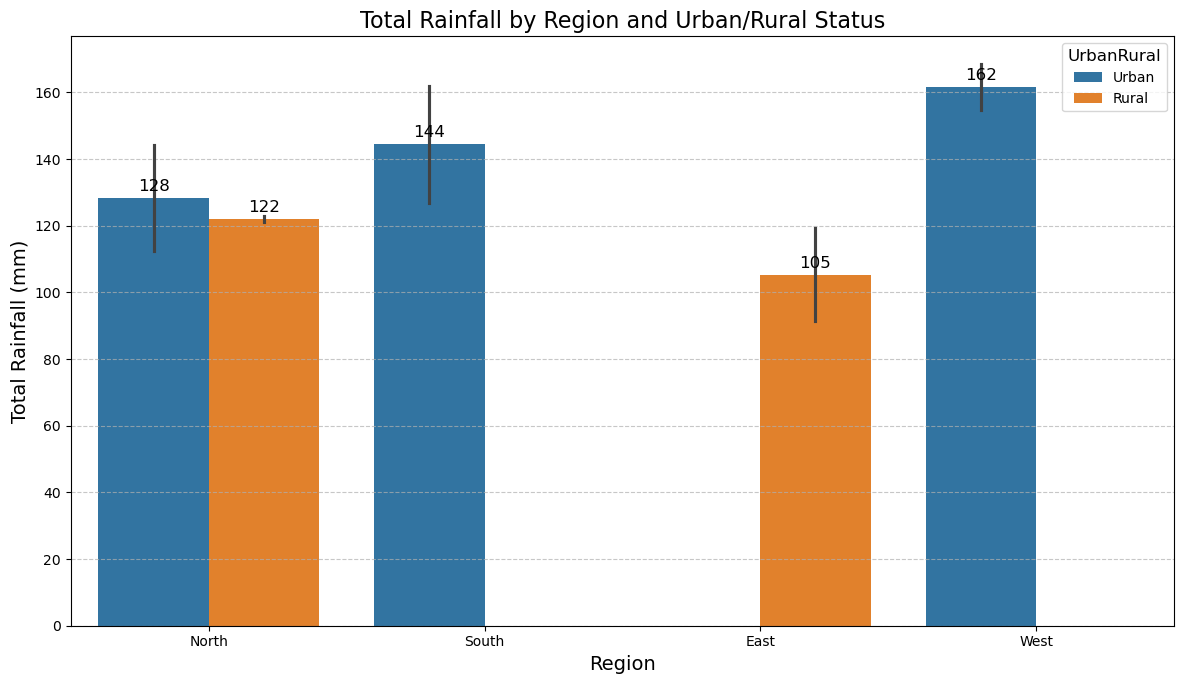

In [293]:
import seaborn as sns

# Setting up global plot parameters for consistency and readability
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10
})

# 1. Bar Chart: Plot total rainfall by region, colored by Urban/Rural.
#    Add value labels, gridlines, axis labels, title, and adjust bar width for clarity.
print("\n1. Generating Bar Chart: Total Rainfall by Region, colored by Urban/Rural...")

fig1, ax1 = plt.subplots(figsize=(12, 7))
sns.barplot(data=rainfall_df, x='Region', y='Rainfall_mm', hue='UrbanRural', estimator=sum, ax=ax1)

ax1.set_title('Total Rainfall by Region and Urban/Rural Status')
ax1.set_xlabel('Region')
ax1.set_ylabel('Total Rainfall (mm)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.0f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()


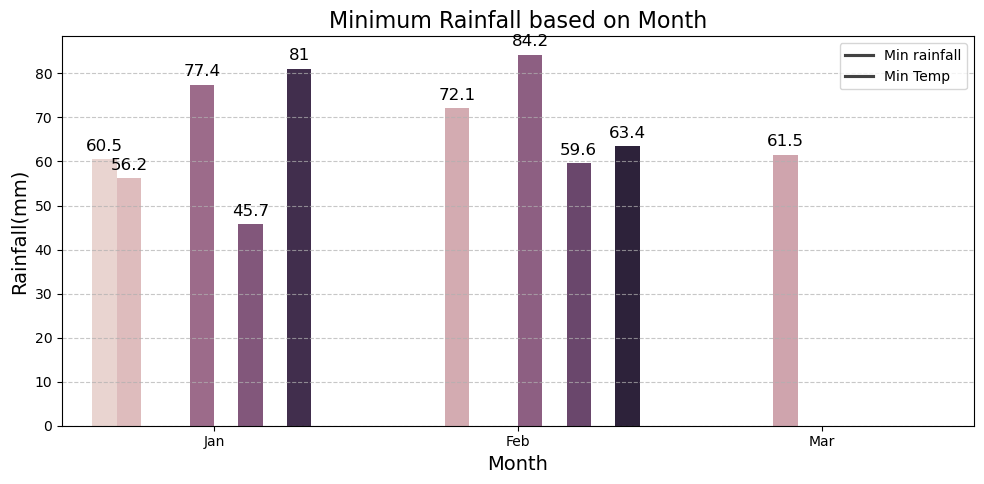

In [354]:
fig, ax = plt.subplots(figsize=(10,5))

sns.barplot(data=rainfall_df, x='Month', y='Rainfall_mm', hue='MinTemp_C', estimator=min, ax=ax)

ax.set_title("Minimum Rainfall based on Month")
ax.set_xlabel("Month")
ax.set_ylabel("Rainfall(mm)")
ax.grid(axis='y', linestyle='--', alpha=0.7)

ax.legend(["Min rainfall","Min Temp"]);

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=4)

plt.tight_layout()
plt.show()




2. **Grouped Bar Chart:**  (6 Marks)
   - Show average monthly rainfall for each station.
   - Use different colors for each station, include a legend, rotate x-tick labels, and increase figure size for readability.



Station,StationA,StationB,StationC,StationD,StationE
Month,,,,,
Feb,72.1,NaN,63.4,59.6,84.2
Jan,56.2,60.5,81.0,45.7,77.4
Mar,NaN,61.5,NaN,NaN,NaN


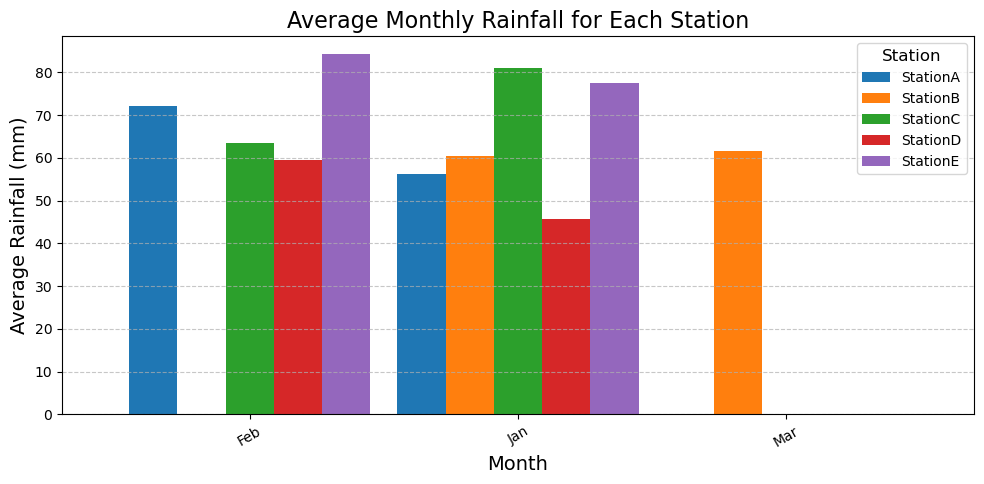

In [436]:
#Write your code here
fig1, ax1 = plt.subplots(figsize=(10,5))

average_rainfallmonth = rainfall_df.groupby(['Month','Station'])['Rainfall_mm'].mean().unstack()
average_rainfallmonth.plot(kind='bar', ax=ax1, width=0.9)
display(average_rainfallmonth)

ax1.set_title('Average Monthly Rainfall for Each Station')
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Rainfall (mm)')
ax1.legend(title='Station')

plt.xticks(rotation=30)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

3. **Line Plot:**  (6 Marks)
   - Show the trend of rainfall over months for at least two selected stations.
   - Use markers, dashed lines, highlight the month with maximum rainfall, and format the x-axis for months.



In [41]:
#Write your code here
fig3, ax3 = plt.subplots(figsize(10,6))




4. **Boxplot:**  (6 Marks)
   - Display rainfall distributions by region and by Urban/Rural.
   - Use custom box colors, highlight outliers, and set y-axis limits.



In [43]:
#Write your code here



5. **Scatter Plot:**  (6 Marks)
   - Visualize the relationship between rainfall and maximum temperature, colored by region.
   - Add axis labels, legend, gridlines, and an appropriate title.



In [45]:
#Write your code here



6. **Heatmap:**  
   - Create a heatmap showing mean monthly rainfall for each region (Month on x-axis, Region on y-axis).
   - Add color bar, axis labels, and title.



In [47]:
#Write your code here



7. **Formatting (for all plots):** (8 Marks)
   - Use descriptive titles, axis labels, and legends.
   - Increase font size for readability.
   - Save each figure as an image file (`.png`).
   - Use `plt.tight_layout()` for proper spacing.

In [49]:
#Write your code here



## Part 4: Bonus Tasks (15 Marks)

1. Annotate at least one plot with the value and label of the highest/lowest point. (5 Marks)


In [51]:
#Write your code here



2. Create a **facet/grid plot** comparing rainfall trends by region and Urban/Rural status. (5 Marks)


In [53]:
#Write your code here



3. Write a brief summary (in a Markdown cell) of your main insights from the data and visualizations. (5 Marks)


#Write your summary here






